# **CDI Sensitivity Analyis**

Data analyzed in this notebook was generated using Netlogo's BehaviorSpace tool. The simulation itself supports adjustable variable populations, but this analysis uses a controlled dataset to isolate the relationship between economic conditions and social contagion.

**Control Variables:** Initial seniors (20), initial juniors (80), initial recruiters (5)

**Independent Variable:** City Development Index (0.2 - 0.8)

**Sample Size:** 70 total simulations (10 repetitions per scenario to account for stochasticity)

In [1]:
# preprocessing
import pandas as pd
import numpy as np

# ignore NetLogo setup text by skipping first few rows
url = 'https://raw.githubusercontent.com/eportah/Brain-drain-simulation/refs/heads/main/cdi_experiment_results.csv'
df = pd.read_csv(url, skiprows=6)

# standardize columns for reading simplicity
df.rename(columns={'[run number]': 'run', '[step]': 'tick'}, inplace=True)

# preview data to ensure data types and headers load correctly
print(df.head())

   run  city-development-index  initial-juniors  initial-recruiters  \
0    5                     0.2               80                   5   
1    6                     0.2               80                   5   
2    2                     0.2               80                   5   
3    4                     0.2               80                   5   
4    3                     0.2               80                   5   

   initial-seniors  tick  total-exits  initial-juniors.1  initial-seniors.1  
0               20     0            0                 80                 20  
1               20     0            0                 80                 20  
2               20     0            0                 80                 20  
3               20     0            0                 80                 20  
4               20     0            0                 80                 20  


### Table 01: Raw Experimental Data Preview

Displays the first five rows of the dataset generated by BehaviorSpace. Ensures the variables were exported correctly.



**Run:** Unique id for each of the 70 simulations

**TIck:** The time step representing 1 business week

**Total-exits:** Dependent variable, cumulative resignations

**CDI:** Independent variable, economic environmental factor

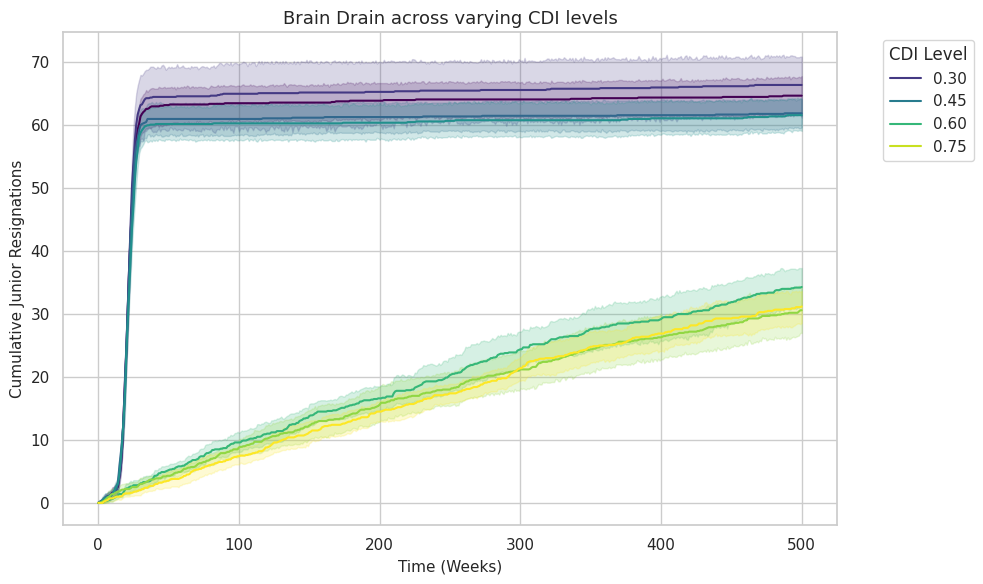

In [2]:
# time-series analysis
import matplotlib.pyplot as plt
import seaborn as sns

# calculates mean and confidence interval, shows simulation's statistical reliability
# hue shows how a healthy company transitions into a failing one (high CDI to low CDI)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='tick', y='total-exits', hue='city-development-index', palette='viridis')

# add labels
plt.title("Brain Drain across varying CDI levels", fontsize=13)
plt.xlabel("Time (Weeks)", fontsize=11) # 1 tick = 1 week
plt.ylabel("Cumulative Junior Resignations", fontsize=11)

# ensure the legend doesn't obstruct the data once displayed
plt.legend(title="CDI Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Figure 01: Cumulative Workforce Attrition

Tracks total number of junior resignations over time (500 weeks).

Solid lines represent average exit count across 10 repetitions, while shaded area represents confidence interval.

Low CDI values reach a plateau almost instantly, while high CDI levels remain stable.

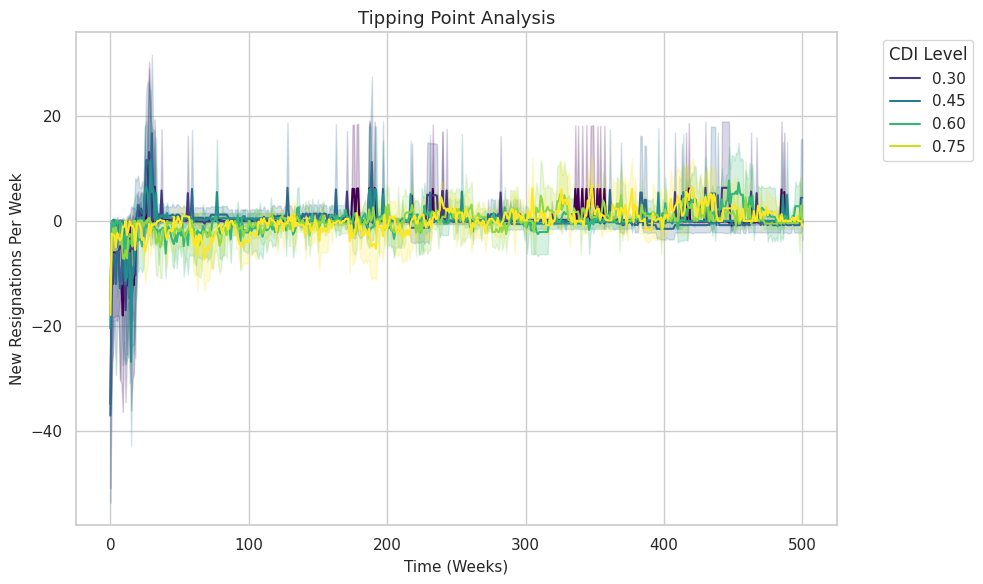

In [3]:
# tipping point and velocity analysis
#.diff() is used to find rate of change between each week
df['exits_per_tick'] = df.groupby('city-development-index')['total-exits'].diff().fillna(0)

# plotting new resignations per week helps pinpoint the panic phase
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='tick', y='exits_per_tick', hue='city-development-index', palette='viridis')

# add labels
plt.title("Tipping Point Analysis", fontsize=13)
plt.xlabel("Time (Weeks)", fontsize=11)
plt.ylabel("New Resignations Per Week", fontsize=11)

# ensure the legend doesn't obstruct the data once displayed
plt.legend(title="CDI Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Figure 02: Resignation Velocity and Social Contagion

Plots how many new people quit each week, with spikes representing the social contagion.

Massive spikes around week 50-100 for the 0.4 CDI show the exact moment the tipping point was reached.

In [4]:
# statistical analysis and summary

# group by run and use tail to extract end state of each simulation
final_states = df.groupby(['city-development-index', 'run']).tail(1).copy()

# dynamic failure threshold, defined as more than 50% of starting junior population leaving
final_states['mass_resignation_occurred'] = (final_states['total-exits'] > (final_states['initial-juniors'] / 2)).astype(int)

# calculate averages and keep track of starting number
summary_10_runs = final_states.groupby('city-development-index').agg(
    avg_final_exits=('total-exits', 'mean'),
    starting_juniors=('initial-juniors', 'first'),
    prob_collapse=('mass_resignation_occurred', lambda x: x.mean() * 100)
).reset_index()

# calculate dynamic survival rate, key performance indicator (KPI)
summary_10_runs['Survival Rate (%)'] = ((summary_10_runs['starting_juniors'] - summary_10_runs['avg_final_exits']) / summary_10_runs['starting_juniors']) * 100

# results
print("Final Experimental Results (Averaged over 10 repetitions)")
display(summary_10_runs.round(2))

Final Experimental Results (Averaged over 10 repetitions)


,city-development-index,avg_final_exits,starting_juniors,prob_collapse,Survival Rate (%)
0,0.2,64.7,80,100.0,19.12
1,0.3,66.4,80,100.0,17.00
2,0.4,61.9,80,100.0,22.62
3,0.5,61.6,80,100.0,23.00
4,0.6,34.3,80,0.0,57.12
5,0.7,30.6,80,10.0,61.75
6,0.8,31.2,80,0.0,61.00


### Table 02: Statistical Analysis and Probability of Collapse

Provides the numbers required to validate the simulation's results.

The correlation between lower CDI and higher prob_collapse mirrors the real-world patterns in low-CDI environments, similar to the Brain Drain trends identified in HR analytics.

**avg_final_exits:** Average total number of juniors who quit across all repetitions for that specific CDI level.

**prob_collapse:** Probability that the company will experience a mass resignation event given the specific CDI conditions.

**Survival rate:** Represents the final percentage of juniors that stayed at the company by the end of the simulation, acts as the KPI for workforce stability.